# Cats vs Dogs Image Classifier
This notebook trains a Convolutional Neural Network (CNN) using TensorFlow/Keras to classify images of cats and dogs.  

We will:
- Load the dataset from `PetImages` folder
- Clean any corrupt images
- Preprocess images
- Build a CNN model
- Train and evaluate the model
- Visualize sample predictions

In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
from PIL import Image
import matplotlib.pyplot as plt

2026-02-24 12:40:23.844370: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


### Cleaning Dataset
Some images in `PetImages` might be corrupted and cannot be read.  
This code goes through each image and removes any file that causes errors.

In [2]:
for folder in ["data/Cat", "data/Dog"]:
    for file in os.listdir(folder):
        path = os.path.join(folder, file)
        try:
            img = Image.open(path)
            img.verify()
        except:
            os.remove(path)

print("Dataset cleaned!")

/Users/suhaspatil/opt/miniconda3/envs/deep_learning/lib/python3.10/site-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Dataset cleaned!


### Data preprocessing 
- Rescale pixel values to [0,1] by dividing by 255
- Use 80% of images for training and 20% for validation
- Resize images to 128x128 pixels
- `class_mode='binary'` because we have 2 classes: Cat & Dog

In [ ]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = datagen.flow_from_directory(
    "data",
    target_size=(128,128),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_generator = datagen.flow_from_directory(
    "data",
    target_size=(128,128),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 20000 images belonging to 2 classes.
Found 4998 images belonging to 2 classes.


### CNN Architecture
- 3 Convolutional layers followed by MaxPooling
- Flatten layer to convert 2D features to 1D
- Dense layer of 128 units with ReLU
- Dropout for regularization
- Output layer with sigmoid activation for 2-class prediction
- Loss: Binary Crossentropy, Optimizer: Adam

In [ ]:
model = Sequential([
    Conv2D(16, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  
])


model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.summary()

/Users/suhaspatil/opt/miniconda3/envs/deep_learning/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,629,473 (6.22 MB)

 Trainable params: 1,629,473 (6.22 MB)

 Non-trainable params: 0 (0.00 B)

### Training the Model
- Train the CNN for 5 epochs
- Monitor validation accuracy to check for overfitting
- `history` stores training and validation loss/accuracy for visualization

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 124s 195ms/step - accuracy: 0.6826 - loss: 0.5838 - val_accuracy: 0.7641 - val_loss: 0.4907
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 114s 182ms/step - accuracy: 0.7892 - loss: 0.4563 - val_accuracy: 0.8075 - val_loss: 0.4315
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 129s 207ms/step - accuracy: 0.8250 - loss: 0.3947 - val_accuracy: 0.8185 - val_loss: 0.3966
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 125s 199ms/step - accuracy: 0.8483 - loss: 0.3451 - val_accuracy: 0.8361 - val_loss: 0.3690
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 125s 200ms/step - accuracy: 0.8716 - loss: 0.2985 - val_accuracy: 0.8387 - val_loss: 0.3611


### Accuracy & Loss Curves
Visualizing training and validation metrics helps:
- Check if the model is learning
- Detect overfitting or underfitting

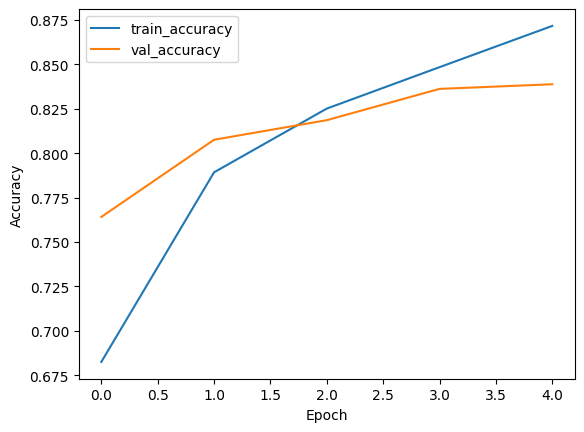

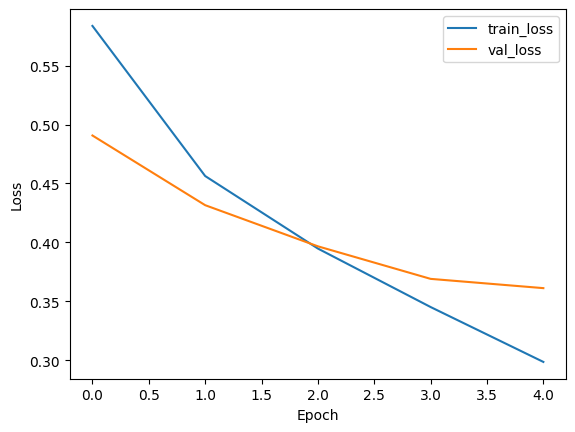

In [ ]:
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

### Visualize Predictions
- Take a few images from validation set
- Predict class using the trained model
- Compare predicted labels with actual labels

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step


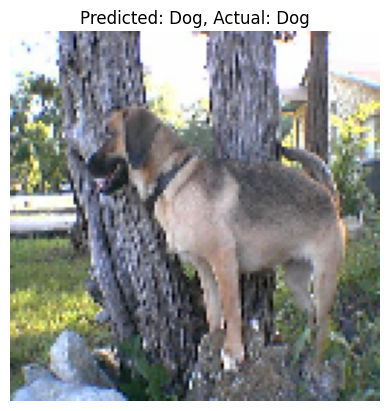

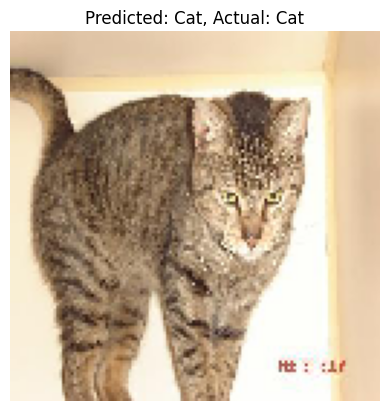

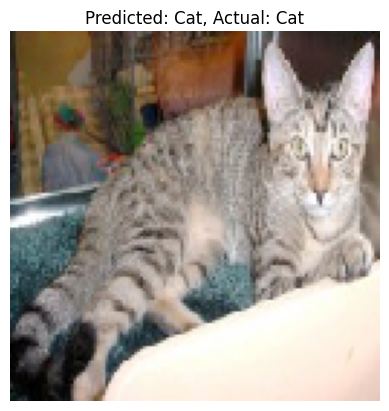

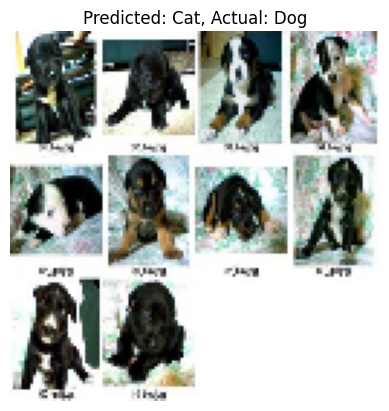

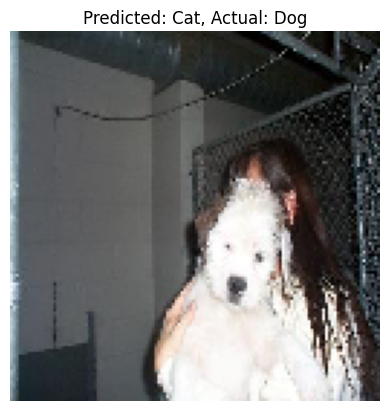

In [ ]:
images, labels = next(iter(val_generator))

preds = model.predict(images)
predicted_labels = ['Dog' if p>0.5 else 'Cat' for p in preds]

for i in range(5):
    plt.imshow(images[i])
    plt.title(f"Predicted: {predicted_labels[i]}, Actual: {'Dog' if labels[i]==1 else 'Cat'}")
    plt.axis('off')
    plt.show()